# Ethiopia Climate Data Analysis (2015–2026)

## Objective
This notebook analyzes climate data to identify trends and patterns.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading

The dataset is loaded from a local CSV file. A new column is added to indicate the country for easier identification during analysis.

In [4]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


## Date Conversion

The dataset provides YEAR and DOY (Day of Year). These are combined to create a proper datetime column, which is necessary for time series analysis. A Month column is also extracted for seasonal analysis.

In [5]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

df[["YEAR", "DOY", "Date", "Month"]].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


## Handling Missing Values

The dataset may contain -999 values, which represent missing or invalid data from the source. These are replaced with NaN to avoid distortion in statistical analysis.

In [14]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


## Duplicate Records

We check for duplicate rows in the dataset to ensure data integrity.

In [15]:
duplicates = df.duplicated().sum()
duplicates

df.drop_duplicates(inplace=True)


duplicate rows were detected and removed.

## Summary Statistics

Basic descriptive statistics are computed to understand the distribution of climate variables such as temperature, precipitation, and humidity.

In [16]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation

- The mean temperature (T2M) indicates generally mild to warm conditions.
- The maximum temperature (T2M_MAX) shows occasional high-temperature extremes, which may indicate heat stress periods.
- Precipitation (PRECTOTCORR) appears highly variable, suggesting seasonal rainfall patterns.
- Relative humidity (RH2M) values suggest moderate atmospheric moisture levels.

## Missing Value Analysis

We evaluate the number and percentage of missing values in each column to assess data quality.

In [17]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": missing_percent
})

,Missing Values,Percentage (%)
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with more than 5% missing values may require careful handling, such as imputation or exclusion, depending on their importance to the analysis. We have no missing values here.

## Outlier Detection

Z-scores are used to identify extreme values in selected climate variables. Observations with absolute Z-score greater than 3 are considered potential outliers.

In [9]:
import scipy
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
outliers

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

### Interpretation

Outlier analysis shows that precipitation (PRECTOTCORR) has the highest number of extreme values, indicating significant variability in rainfall patterns and the presence of intense rainfall events.

Minimum temperature (T2M_MIN) also shows a notable number of outliers, suggesting occasional unusual low-temperature conditions during certain periods.

Relative humidity (RH2M) presents some variability, while other variables such as mean temperature (T2M) and wind speed show relatively few extreme values, indicating more stable patterns.

These outliers are likely to represent real climate phenomena rather than data errors, and therefore will be retained for further analysis.

## Handling Missing Values

Missing values are handled using forward-fill for continuous weather variables. Rows with excessive missing data may be dropped to maintain data quality.

In [7]:
##df.fillna(method='ffill', inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia


Forward-fill is applied to preserve temporal continuity in the dataset. This approach assumes that short gaps in measurements can be approximated using previous observations.

Rows with excessive missing values are removed to avoid unreliable analysis.

In [8]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

The cleaned dataset is saved for further analysis and cross-country comparison.

## Temperature Trend Analysis

We analyze monthly average temperature (T2M) over time to identify long-term trends and seasonal patterns.

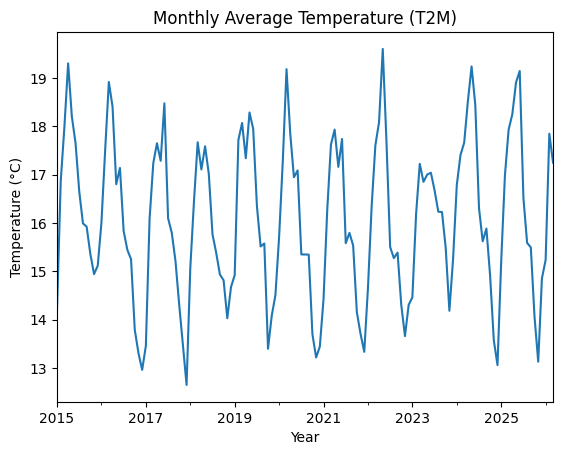

In [16]:
# Create a time-indexed DataFrame
df_time = df.set_index("Date")

# Monthly average temperature
monthly_temp = df_time["T2M"].resample("ME").mean()

# Plot
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation

The temperature trend exhibits strong and consistent seasonal fluctuations, with recurring peaks and troughs across all years. This indicates a stable and predictable annual temperature cycle.

While the overall trend appears relatively stable, there are slight increases in peak temperatures in more recent years, which may suggest early signs of gradual warming.

These recurring high-temperature periods could contribute to heat stress, particularly during peak months, with potential implications for agriculture and water demand.

## Seasonal Temperature Pattern

To better understand seasonal behavior, we examine the average temperature for each month across all years.

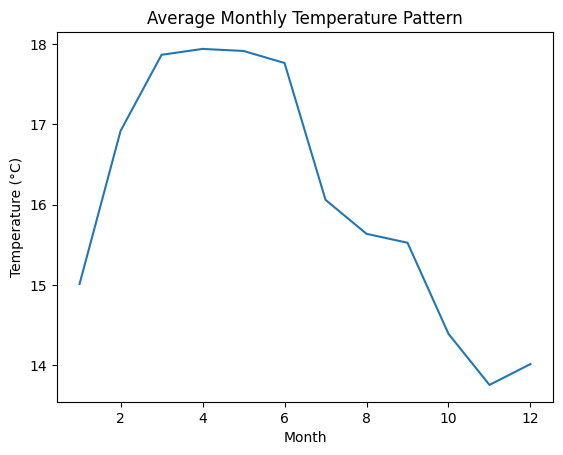

In [17]:
monthly_temp_pattern = df.groupby("Month")["T2M"].mean()

plt.figure()
monthly_temp_pattern.plot()
plt.title("Average Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

### Interpretation

The seasonal temperature pattern shows a clear and consistent annual cycle. Temperatures increase steadily from the beginning of the year, peaking between March and May, before gradually declining toward the end of the year.

This pattern indicates well-defined warm and cool periods, suggesting a stable climate system with predictable seasonal transitions.

Such predictability is important for agricultural planning, as crop cycles and water usage can be aligned with expected temperature conditions.

## Precipitation Analysis

We examine monthly total precipitation to identify rainfall patterns and seasonal peaks.

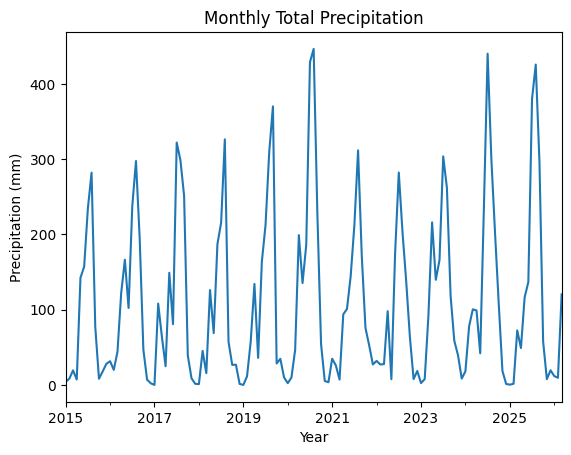

In [18]:
monthly_rain = df_time["PRECTOTCORR"].resample("ME").sum()

plt.figure()
monthly_rain.plot()
plt.title("Monthly Total Precipitation")
plt.xlabel("Year")
plt.ylabel("Precipitation (mm)")
plt.show()

### Interpretation

The precipitation trend shows high variability, with sharp spikes indicating periods of intense rainfall followed by extended low-rainfall periods.

This irregular pattern suggests that rainfall is not evenly distributed over time, with significant fluctuations between wet and dry conditions.

Such variability increases the risk of both flooding during peak rainfall periods and drought during prolonged dry spells, highlighting potential climate vulnerability.

## Seasonal Precipitation Pattern

We examine the average precipitation for each month to better understand the timing and concentration of rainy seasons.

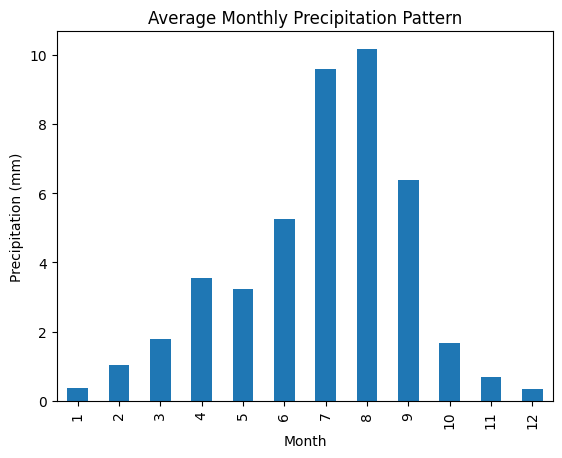

In [19]:
monthly_rain_pattern = df.groupby("Month")["PRECTOTCORR"].mean()

plt.figure()
monthly_rain_pattern.plot(kind="bar")
plt.title("Average Monthly Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

### Interpretation

The seasonal precipitation pattern reveals a well-defined rainy season, with rainfall increasing from May and peaking sharply in July and August, before declining in the following months.

Conversely, the early and late months of the year experience very low precipitation, indicating pronounced dry seasons.

This strong seasonal concentration of rainfall suggests a heavy dependence on a limited wet period, making the region particularly sensitive to shifts in rainfall timing or intensity.

## Correlation Analysis

We examine relationships between key climate variables using a correlation matrix. This helps identify how different environmental factors interact with each other.

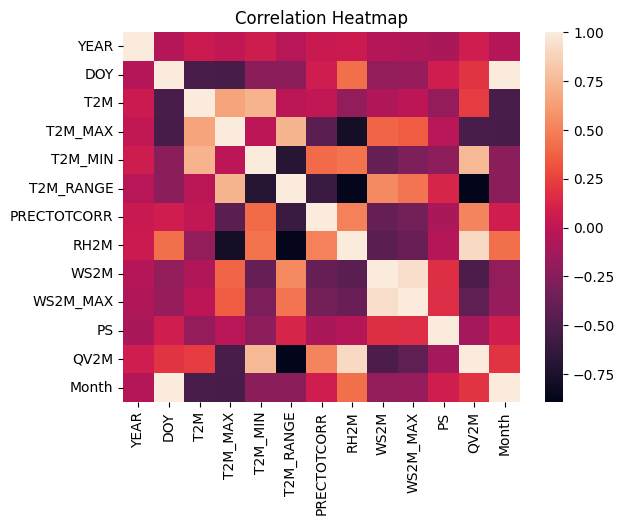

In [7]:
corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Interpretation

The correlation matrix highlights strong positive relationships among temperature variables (T2M, T2M_MAX, and T2M_MIN), indicating consistency in temperature measurements.

Precipitation shows a positive relationship with relative humidity, confirming that higher atmospheric moisture is associated with increased rainfall.

Temperature variables tend to show weak or negative relationships with precipitation and humidity, suggesting that warmer conditions are not directly linked to rainfall events.

Wind-related variables exhibit relatively weak correlations with other features, indicating a limited direct influence on temperature and precipitation patterns.

## Variable Relationships

Scatter plots are used to further explore relationships between key variables identified in the correlation analysis.

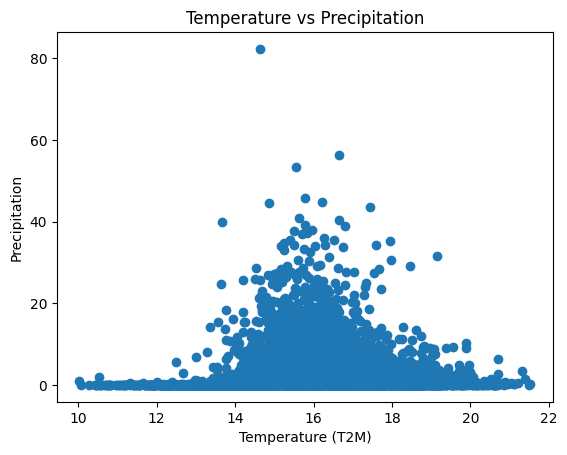

In [8]:
plt.figure()
plt.scatter(df["T2M"], df["PRECTOTCORR"])
plt.xlabel("Temperature (T2M)")
plt.ylabel("Precipitation")
plt.title("Temperature vs Precipitation")
plt.show()

### Temperature vs Precipitation Interpretation

The relationship between temperature and precipitation appears weak and non-linear.

Most rainfall events occur within a moderate temperature range, while very high temperatures are generally associated with little to no precipitation.

This suggests that temperature alone is not a strong predictor of rainfall, and that other factors, such as humidity, play a more critical role.

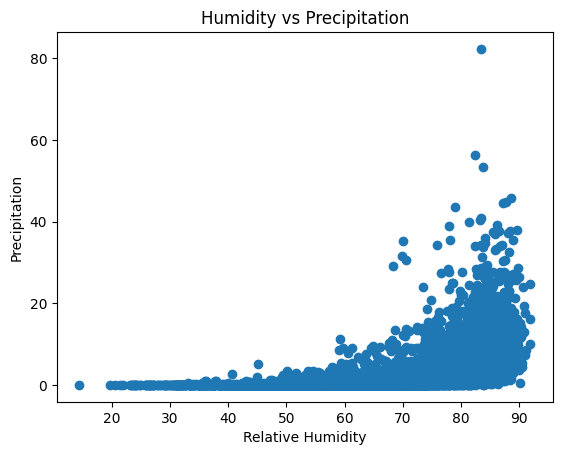

In [9]:
plt.figure()
plt.scatter(df["RH2M"], df["PRECTOTCORR"])
plt.xlabel("Relative Humidity")
plt.ylabel("Precipitation")
plt.title("Humidity vs Precipitation")
plt.show()

### Humidity vs Precipitation

The scatter plot shows a clear positive relationship between relative humidity and precipitation.

At lower humidity levels, precipitation is minimal or absent. As humidity increases, the likelihood and intensity of rainfall also increase, with higher precipitation values concentrated at higher humidity levels.

This indicates that atmospheric moisture plays a significant role in rainfall formation, making humidity a strong indicator of precipitation events.

## Key Takeaways

- The climate exhibits strong seasonal patterns, with predictable temperature cycles throughout the year.
- Rainfall is highly variable and concentrated within a specific wet season, particularly between June and September.
- Precipitation is strongly associated with relative humidity, highlighting the importance of atmospheric moisture in rainfall formation.
- Temperature shows limited direct influence on precipitation, indicating that rainfall is driven by multiple interacting factors.
- The presence of extreme precipitation values suggests potential exposure to climate risks such as flooding and drought.

These findings provide a foundation for comparing climate patterns across other countries in the dataset.